# Atividade 1 — Expected values, Surprise, Entropy, Cross-entropy loss, Softmax e True labels

As fórmulas-base usadas são:

$$
I(x)=-\log_2(P(x))
$$

$$
H(p)=-\sum_i p_i\log_2(p_i)
$$

$$
H(p,q)=-\sum_i p_i\log_2(q_i)
$$

$$
\text{softmax}(z_i)=\frac{e^{z_i}}{\sum_j e^{z_j}}
$$


## Requisitos da atividade

![](imagens/inst_1.png)

![](imagens/inst_2.png)

![](imagens/inst_3.png)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng()
pd.set_option('display.precision', 6)


## Parte A — Entropy and Cross-entropy

![](imagens/a_1.png)

![](imagens/a_2.png)

![](imagens/a_3.png)


### Ideia da Parte A

O dado começa viciado, com $P(1)=P(6)=0{,}25$. As faces 2, 3, 4 e 5 dividem igualmente a probabilidade restante:

$$
\frac{1-0{,}25-0{,}25}{4}=0{,}125
$$

A **surprise** de um resultado é:

$$
I(x)=-\log_2(P(x))
$$

A **entropy** é a média teórica da surprise:

$$
H(p)=-\sum_i p_i\log_2(p_i)
$$

A **cross entropy** entre a distribuição atual $p$ e o dado justo $q$ é:

$$
H(p,q)=-\sum_i p_i\log_2(q_i)
$$


In [2]:
def entropy(p):
    p = np.array(p, dtype=float)
    return -np.sum(p * np.log2(p))

def cross_entropy(p, q):
    p = np.array(p, dtype=float)
    q = np.array(q, dtype=float)
    return -np.sum(p * np.log2(q))

def surprise(p):
    p = np.array(p, dtype=float)
    return -np.log2(p)


In [3]:
faces = np.array([1, 2, 3, 4, 5, 6])
p_ini = np.array([0.25, 0.125, 0.125, 0.125, 0.125, 0.25])
p_justo = np.ones(6) / 6

lanc = rng.choice(faces, size=100, p=p_ini)
surp_obs = surprise(p_ini)[lanc - 1]

ent_teo = entropy(p_ini)
ent_obs = np.mean(surp_obs)
ce_ini = cross_entropy(p_ini, p_justo)

print('Distribuição inicial:', p_ini)
print('Entropy teórica:', ent_teo)
print('Surprise média observada:', ent_obs)
print('Cross entropy:', ce_ini)
print('Diferença:', ce_ini - ent_teo)


Distribuição inicial: [0.25  0.125 0.125 0.125 0.125 0.25 ]
Entropy teórica: 2.5
Surprise média observada: 2.54
Cross entropy: 2.584962500721156
Diferença: 0.08496250072115608


In [4]:
iters = np.arange(31)
k = 0.18
alvo = 1/6
p16 = alvo + (0.25 - alvo) * np.exp(-k * iters)

hist = []
for i, valor in zip(iters, p16):
    resto = 1 - 2 * valor
    meio = resto / 4
    p = np.array([valor, meio, meio, meio, meio, valor])
    ent = entropy(p)
    ce = cross_entropy(p, p_justo)
    hist.append([i, *p, ent, ce, ce - ent])

cols = ['iter', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'entropy', 'cross_entropy', 'dif']
df_a = pd.DataFrame(hist, columns=cols)
display(df_a.head())
display(df_a.tail())


,iter,P1,P2,P3,P4,P5,P6,entropy,cross_entropy,dif
0,0,0.250000,0.125000,0.125000,0.125000,0.125000,0.250000,2.500000,2.584963,0.084963
1,1,0.236273,0.131864,0.131864,0.131864,0.131864,0.236273,2.525279,2.584963,0.059684
2,2,0.224806,0.137597,0.137597,0.137597,0.137597,0.224806,2.543049,2.584963,0.041913
3,3,0.215229,0.142385,0.142385,0.142385,0.142385,0.215229,2.555543,2.584963,0.029420
4,4,0.207229,0.146385,0.146385,0.146385,0.146385,0.207229,2.564324,2.584963,0.020639


,iter,P1,P2,P3,P4,P5,P6,entropy,cross_entropy,dif
26,26,0.167440,0.166280,0.166280,0.166280,0.166280,0.167440,2.584955,2.584963,0.000008
27,27,0.167313,0.166344,0.166344,0.166344,0.166344,0.167313,2.584957,2.584963,0.000005
28,28,0.167206,0.166397,0.166397,0.166397,0.166397,0.167206,2.584959,2.584963,0.000004
29,29,0.167117,0.166441,0.166441,0.166441,0.166441,0.167117,2.584960,2.584963,0.000003
30,30,0.167043,0.166478,0.166478,0.166478,0.166478,0.167043,2.584961,2.584963,0.000002


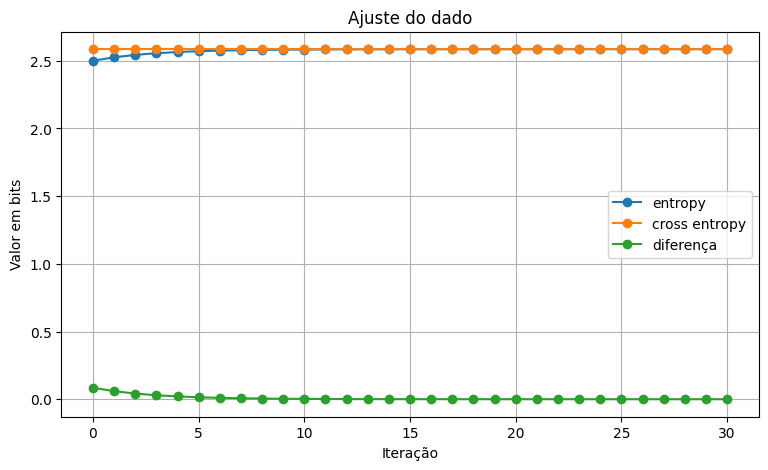

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(df_a['iter'], df_a['entropy'], marker='o', label='entropy')
plt.plot(df_a['iter'], df_a['cross_entropy'], marker='o', label='cross entropy')
plt.plot(df_a['iter'], df_a['dif'], marker='o', label='diferença')
plt.xlabel('Iteração')
plt.ylabel('Valor em bits')
plt.title('Ajuste do dado')
plt.legend()
plt.grid(True)
plt.show()


### Análise dos resultados da Parte A

A função `entropy(p)` implementa $H(p)=-\sum_i p_i\log_2(p_i)$ e mede a incerteza média da distribuição. Quanto mais equilibradas forem as probabilidades, maior é a entropy. No dado justo, a entropy máxima seria $\log_2(6)$.

A função `surprise(p)` calcula $I(x)=-\log_2(P(x))$. Ela mostra que eventos menos prováveis geram maior surprise. Por isso, no dado inicial, as faces 2, 3, 4 e 5 causam mais surprise do que as faces 1 e 6.

A função `cross_entropy(p, q)` calcula $H(p,q)=-\sum_i p_i\log_2(q_i)$. Aqui, $p$ é o dado atual e $q$ é o dado justo. A diferença entre cross entropy e entropy diminui quando o dado se aproxima da distribuição uniforme.

A atualização usa decaimento exponencial:

$$
P_t=P_{alvo}+(P_{inicial}-P_{alvo})e^{-kt}
$$

Conforme $P(1)$ e $P(6)$ caminham para $1/6$, as outras faces são recalculadas para manter $\sum P=1$. O gráfico mostra que a entropy cresce em direção ao máximo e a diferença entre as métricas tende a zero.


## Parte B — Surprise

![](imagens/b_1.png)

![](imagens/b_2.png)

![](imagens/b_3.png)


### Ideia da Parte B

Foram simuladas três moedas:

- moeda justa: $[0{,}5,0{,}5]$;
- moeda 90/10: $[0{,}9,0{,}1]$;
- moeda do slide: $[0{,}49,0{,}49,0{,}02]$.

A terceira foi tratada como uma moeda com três possibilidades: dois resultados comuns e um resultado raro.

A surprise média teórica é:

$$
\mathbb{E}[I(X)]=\sum_i p_i(-\log_2(p_i))
$$


In [6]:
moedas = {
    'justa': np.array([0.5, 0.5]),
    '90/10': np.array([0.9, 0.1]),
    'slide': np.array([0.49, 0.49, 0.02])
}

reps = [10, 100, 1000]
linhas = []

for nome, p in moedas.items():
    outs = np.arange(len(p))
    s = surprise(p)
    linhas.append([nome, 'teórico', entropy(p)])
    for n in reps:
        amostra = rng.choice(outs, size=n, p=p)
        linhas.append([nome, str(n), np.mean(s[amostra])])

df_b = pd.DataFrame(linhas, columns=['moeda', 'tipo', 'surprise_media'])
display(df_b)


,moeda,tipo,surprise_media
0,justa,teórico,1.000000
1,justa,10,1.000000
2,justa,100,1.000000
3,justa,1000,1.000000
4,90/10,teórico,0.468996
5,90/10,10,0.785988
6,90/10,100,0.405597
7,90/10,1000,0.494355
8,slide,teórico,1.121441
9,slide,10,1.029146


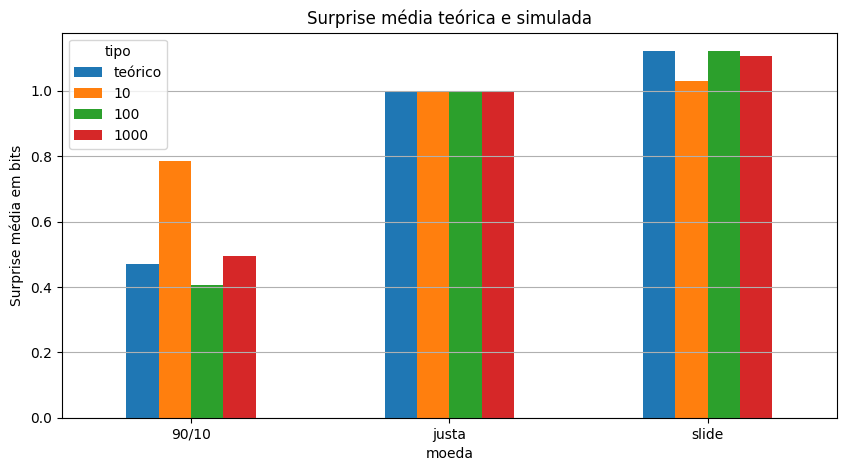

In [7]:
tab_b = df_b.pivot(index='moeda', columns='tipo', values='surprise_media')
tab_b = tab_b[['teórico', '10', '100', '1000']]

tab_b.plot(kind='bar', figsize=(10, 5))
plt.ylabel('Surprise média em bits')
plt.title('Surprise média teórica e simulada')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


### Análise dos resultados da Parte B

A função `surprise(p)` aplica $I(x)=-\log_2(P(x))$. Eventos raros geram valores maiores, então o resultado de probabilidade $0{,}02$ na moeda do slide tem surprise alta.

A função `entropy(p)` calcula a média teórica da surprise. Em 10 repetições, o resultado simulado pode oscilar bastante, porque a amostra é pequena. Em 100 e principalmente em 1000 repetições, a média simulada tende a se aproximar do valor teórico.

A moeda justa tem maior incerteza entre moedas de dois resultados porque as duas saídas têm a mesma probabilidade. A moeda 90/10 é mais previsível, então sua surprise média é menor. A moeda do slide possui um evento raro, e por isso a média simulada depende bastante de quantas vezes esse evento aparece.


## Parte C — Entropia, softmax, logits e cross-entropy loss

![](imagens/c_1.png)

![](imagens/c_2.png)

![](imagens/c_3.png)

![](imagens/c_4.png)

![](imagens/c_5.png)

![](imagens/c_6.png)

![](imagens/c_7.png)

![](imagens/c_8.png)


### Ideia da Parte C

Os true labels em one-hot encoded são:

$$
[1,0,0],\quad[0,1,0],\quad[0,0,1]
$$

A softmax usada é a versão estabilizada:

$$
\text{softmax}(z_i)=\frac{e^{z_i-\max(z)}}{\sum_j e^{z_j-\max(z)}}
$$

A cross-entropy loss é:

$$
L=-\sum_i y_i\log(\hat{y}_i)
$$


In [8]:
def softmax(z):
    z = np.array(z, dtype=float)
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def ce_loss(probs, labels):
    eps = 1e-12
    return -np.mean(np.sum(labels * np.log(probs + eps), axis=1))

def ent_media(probs):
    eps = 1e-12
    return -np.mean(np.sum(probs * np.log2(probs + eps), axis=1))


In [9]:
labels = np.eye(3)
logits = rng.uniform(0.1, 3.0, size=(3, 3))
probs = softmax(logits)

print('Raw logits iniciais:')
print(logits)
print('\nProbabilidades:')
print(probs)
print('\nCross-entropy loss inicial:', ce_loss(probs, labels))
print('Entropy média inicial:', ent_media(probs))


Raw logits iniciais:
[[1.78949805 1.76305739 0.61927314]
 [1.73891362 2.20975882 2.07899502]
 [2.66664319 2.58033988 0.62617628]]

Probabilidades:
[[0.43778946 0.42636571 0.13584482]
 [0.24960008 0.39969635 0.35070357]
 [0.48845202 0.44806484 0.06348314]]

Cross-entropy loss inicial: 1.5000160751178313
Entropy média inicial: 1.4241375372958398


In [10]:
desv = 0.35
melhor = logits.copy()
hist_c = []

for ep in range(31):
    probs = softmax(melhor)
    hist_c.append([ep, ce_loss(probs, labels), ent_media(probs)])

    cand = [melhor]
    for _ in range(4):
        cand.append(rng.normal(loc=melhor, scale=desv))

    perdas = [ce_loss(softmax(c), labels) for c in cand]
    melhor = cand[int(np.argmin(perdas))]

df_c = pd.DataFrame(hist_c, columns=['iter', 'cross_entropy_loss', 'entropy_media'])
display(df_c.head())
display(df_c.tail())


,iter,cross_entropy_loss,entropy_media
0,0,1.500016,1.424138
1,1,1.500016,1.424138
2,2,1.369716,1.390178
3,3,1.166257,1.454825
4,4,1.166257,1.454825


,iter,cross_entropy_loss,entropy_media
26,26,0.044682,0.244982
27,27,0.019156,0.146017
28,28,0.018540,0.145388
29,29,0.013303,0.112616
30,30,0.007791,0.071703


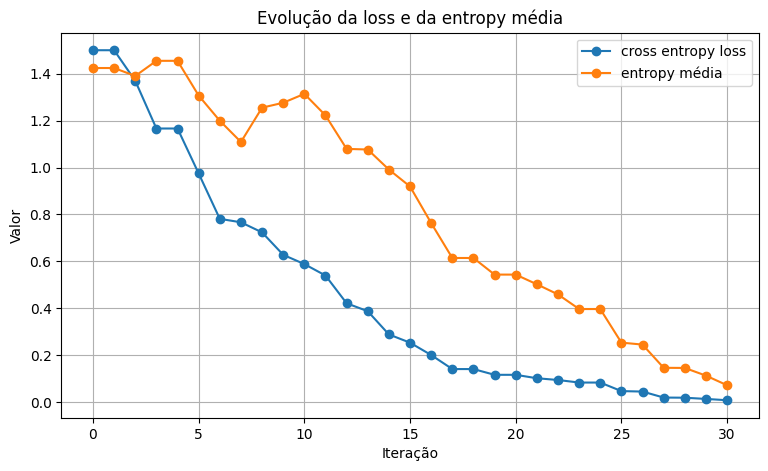

Melhores logits:
[[ 4.67944252 -0.53666569 -2.09150483]
 [-1.07567276  5.45243255 -1.93796008]
 [-1.45888282 -1.23786753  4.26409549]]

Probabilidades finais:
[[9.93467926e-01 5.39295551e-03 1.13911817e-03]
 [1.45874022e-03 9.97925387e-01 6.15873241e-04]
 [3.24610274e-03 4.04900193e-03 9.92704895e-01]]


In [11]:
plt.figure(figsize=(9, 5))
plt.plot(df_c['iter'], df_c['cross_entropy_loss'], marker='o', label='cross entropy loss')
plt.plot(df_c['iter'], df_c['entropy_media'], marker='o', label='entropy média')
plt.xlabel('Iteração')
plt.ylabel('Valor')
plt.title('Evolução da loss e da entropy média')
plt.legend()
plt.grid(True)
plt.show()

print('Melhores logits:')
print(melhor)
print('\nProbabilidades finais:')
print(softmax(melhor))


### Análise dos resultados da Parte C

A função `softmax(z)` transforma cada linha de logits em uma distribuição de probabilidades. A soma de cada linha fica igual a 1. A subtração de `np.max` não altera a relação entre os logits, mas evita problemas numéricos ao calcular exponenciais.

A função `ce_loss(probs, labels)` implementa:

$$
L=-\frac{1}{N}\sum_{n=1}^{N}\sum_{i=1}^{C}y_{n,i}\ln(\hat{y}_{n,i})
$$

Como os labels são one-hot, só a probabilidade da classe correta entra de fato no erro. Se a probabilidade correta é baixa, a loss cresce; se é alta, a loss diminui.

A função `ent_media(probs)` mede a entropy média das distribuições previstas, sem olhar diretamente para o label correto. No processo iterativo, são criadas quatro variações Gaussianas dos logits atuais. A matriz original e as quatro novas são avaliadas, e só a menor cross-entropy loss continua. Isso simula uma busca simples por logits melhores.

A tendência esperada é a cross-entropy loss cair com as iterações, pois o algoritmo sempre preserva a melhor opção encontrada naquela rodada.


## Parte D — Imagem de satélite, softmax e cross entropy

![](imagens/d_1.png)

![](imagens/d_2.png)

![](imagens/d_3.png)


### Ideia da Parte D

O modelo classifica uma imagem em **Floresta**, **Água** ou **Urbano**. A imagem verdadeira é 100% Floresta:

$$
p=[1,0,0]
$$

Os logits iniciais são:

$$
z_{floresta}=2,\quad z_{agua}=1,\quad z_{urbano}=5
$$

O modelo erra porque o maior logit está em Urbano.


In [12]:
classes = np.array(['Floresta', 'Água', 'Urbano'])
z = np.array([[2.0, 1.0, 5.0]])
y = np.array([[1.0, 0.0, 0.0]])

q = softmax(z)
loss = ce_loss(q, y)

print('Classes:', classes)
print('Logits:', z[0])
print('Probabilidades q:', q[0])
print('Classe prevista:', classes[np.argmax(q)])
print('Cross entropy:', loss)
print('-ln(q_floresta):', -np.log(q[0, 0]))


Classes: ['Floresta' 'Água' 'Urbano']
Logits: [2. 1. 5.]
Probabilidades q: [0.04661262 0.01714783 0.93623955]
Classe prevista: Urbano
Cross entropy: 3.0658839037359757
-ln(q_floresta): 3.0658839037574293


In [13]:
traj = np.array([
    [2.0, 1.0, 5.0],
    [3.0, 1.0, 4.0],
    [4.0, 1.0, 3.0],
    [5.0, 1.0, 2.0],
    [6.0, 1.0, 1.0]
])

linhas = []
for i, z_i in enumerate(traj):
    q_i = softmax([z_i])[0]
    loss_i = -np.log(q_i[0])
    linhas.append([i, *z_i, *q_i, loss_i])

cols = ['passo', 'z_flor', 'z_agua', 'z_urb', 'q_flor', 'q_agua', 'q_urb', 'cross_entropy']
df_d = pd.DataFrame(linhas, columns=cols)
display(df_d)


,passo,z_flor,z_agua,z_urb,q_flor,q_agua,q_urb,cross_entropy
0,0,2.0,1.0,5.0,0.046613,0.017148,0.936240,3.065884
1,1,3.0,1.0,4.0,0.259496,0.035119,0.705385,1.349012
2,2,4.0,1.0,3.0,0.705385,0.035119,0.259496,0.349012
3,3,5.0,1.0,2.0,0.936240,0.017148,0.046613,0.065884
4,4,6.0,1.0,1.0,0.986703,0.006648,0.006648,0.013386


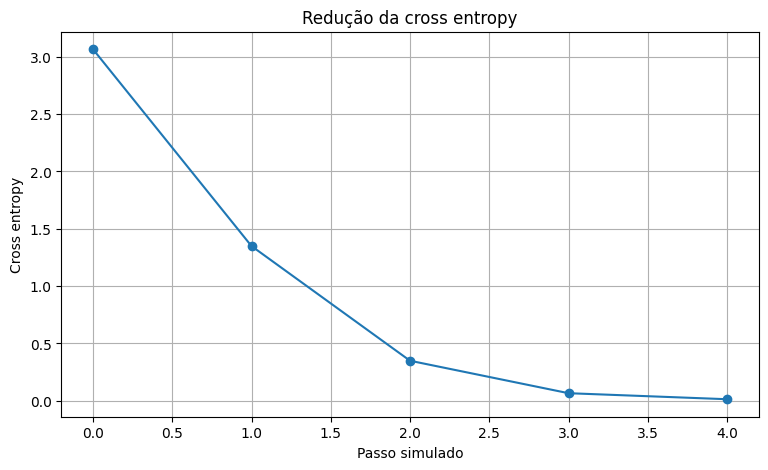

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(df_d['passo'], df_d['cross_entropy'], marker='o')
plt.xlabel('Passo simulado')
plt.ylabel('Cross entropy')
plt.title('Redução da cross entropy')
plt.grid(True)
plt.show()


### Análise dos resultados da Parte D

A cross entropy geral é:

$$
H(p,q)=-\sum_i p_i\ln(q_i)
$$

Como a classe real é Floresta, o vetor real é one-hot:

$$
p=[1,0,0]
$$

Assim, os termos de Água e Urbano somem, porque são multiplicados por zero:

$$
H(p,q)=-(1\cdot\ln(q_{floresta})+0\cdot\ln(q_{agua})+0\cdot\ln(q_{urbano}))
$$

Logo:

$$
L=-\ln(q_{floresta})
$$

Quando o logit de Floresta aumenta e o de Urbano diminui, a softmax passa a colocar mais probabilidade na classe correta. Se $q_{floresta}\to1$, então $-\ln(q_{floresta})\to0$. Por isso, a cross entropy se aproxima da entropy da distribuição real one-hot, que é 0.


## Parte E — Expected values

![](imagens/ppt_slide26.png)

![](imagens/ppt_slide51.png)


### Ideia da Parte E

No slide 26:

- 37 pessoas já ouviram falar de *Troll 2*;
- 176 pessoas nunca ouviram falar de *Troll 2*;
- total de 213 pessoas.

No slide 51:

- ouviu falar: outcome $-1$;
- nunca ouviu falar: outcome $1$.

O valor esperado é:

$$
E[X]=\sum_i p_i x_i
$$


In [15]:
def valor_esp(probs, outs):
    probs = np.array(probs, dtype=float)
    outs = np.array(outs, dtype=float)
    return np.sum(probs * outs)

def sim_ev(probs, outs, n):
    probs = np.array(probs, dtype=float)
    outs = np.array(outs, dtype=float)
    amostra = rng.choice(outs, size=n, p=probs)
    return np.mean(amostra)


In [16]:
cont = np.array([37, 176])
outs = np.array([-1, 1])
probs = cont / np.sum(cont)

ve_teo = valor_esp(probs, outs)

print('Probabilidades:', probs)
print('Outcomes:', outs)
print('Valor esperado teórico:', ve_teo)


Probabilidades: [0.17370892 0.82629108]
Outcomes: [-1  1]
Valor esperado teórico: 0.6525821596244132


In [17]:
reps_e = [10, 100, 1000, 10000]
linhas = []

for n in reps_e:
    ve_sim = sim_ev(probs, outs, n)
    linhas.append([n, ve_teo, ve_sim, abs(ve_sim - ve_teo)])

df_e = pd.DataFrame(linhas, columns=['repeticoes', 'valor_teorico', 'valor_simulado', 'erro_abs'])
display(df_e)


,repeticoes,valor_teorico,valor_simulado,erro_abs
0,10,0.652582,1.0000,0.347418
1,100,0.652582,0.6000,0.052582
2,1000,0.652582,0.6240,0.028582
3,10000,0.652582,0.6476,0.004982


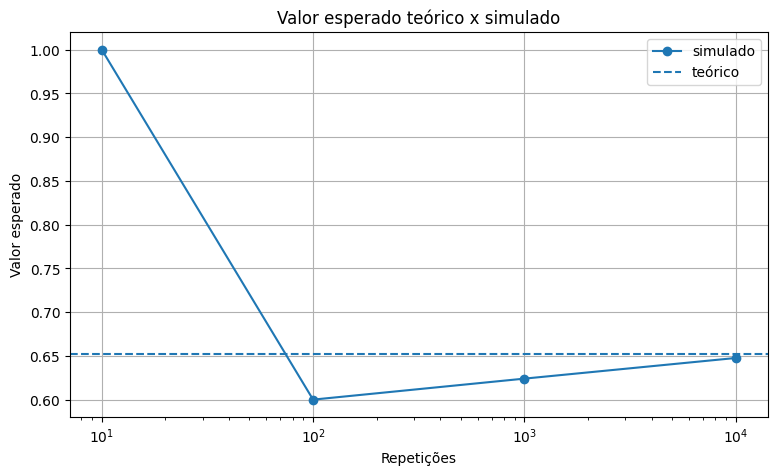

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(df_e['repeticoes'], df_e['valor_simulado'], marker='o', label='simulado')
plt.axhline(ve_teo, linestyle='--', label='teórico')
plt.xscale('log')
plt.xlabel('Repetições')
plt.ylabel('Valor esperado')
plt.title('Valor esperado teórico x simulado')
plt.legend()
plt.grid(True)
plt.show()


### Análise dos resultados da Parte E

A função `valor_esp(probs, outs)` implementa:

$$
E[X]=\sum_i p_i x_i
$$

Com os dados dos slides:

$$
E[X]=\frac{37}{213}(-1)+\frac{176}{213}(1)
$$

$$
E[X]=\frac{139}{213}\approx0{,}6526
$$

Isso significa que a aposta possui valor esperado positivo para quem aposta que a próxima pessoa nunca ouviu falar de *Troll 2*.

A função `sim_ev(probs, outs, n)` sorteia outcomes conforme as probabilidades e calcula a média observada. Com 10 repetições, a simulação pode se afastar do valor teórico. Com 100, 1000 e 10000 repetições, a média tende a se aproximar do valor esperado. Isso é uma aplicação direta da Lei dos Grandes Números.
